In [1]:
# Read Dataset
val_data = "C:/Users/91886/Desktop/My Computer/Project_guvi/fish classification deep learning/data/val"
train_data = "C:/Users/91886/Desktop/My Computer/Project_guvi/fish classification deep learning/data/train"
test_data = "C:/Users/91886/Desktop/My Computer/Project_guvi/fish classification deep learning/data/test"

In [2]:
!pip install tensorflow

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Resize for validation
val_datagen = ImageDataGenerator(rescale=1./255)  # Only rescale
val_generator = val_datagen.flow_from_directory(
    val_data,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

# Resize for test data
test_datagen = ImageDataGenerator(rescale=1./255)  # Only rescale
test_generator = test_datagen.flow_from_directory(
    test_data,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

# Apply augumentation for training data
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize pixel values to [0,1]
    rotation_range=40,  # Random rotation
    width_shift_range=0.2,  # Horizontal shift
    height_shift_range=0.2,  # Vertical shift
    shear_range=0.2,  # Shear transformation
    zoom_range=0.2,  # Random zoom
    horizontal_flip=True  # Flip images
)
train_generator = train_datagen.flow_from_directory(
    train_data,
    target_size=(224, 224),  # Resize all images
    batch_size=32,
    class_mode='categorical',
    color_mode='rgb'
)

Found 1092 images belonging to 11 classes.
Found 3187 images belonging to 11 classes.
Found 6225 images belonging to 11 classes.


In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the CNN model
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 classes for classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Print model summary
model.summary()

c:\Users\91886\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,626,442 (6.20 MB)

 Trainable params: 1,626,442 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten
import pickle

# Define save path
save_path = "C:/Users/91886/Desktop/My Computer/Project_guvi/fish classification deep learning"

# Load the pre-trained VGG16 model
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze the convolutional layers

# Add custom classification layers
x = Flatten()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dense(train_generator.num_classes, activation="softmax")(x)  # Use number of classes from augmented data

model = Model(inputs=base_model.input, outputs=x)

# Compile the model
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Train the model using augmented dataset
history = model.fit(train_generator, validation_data=val_generator, epochs=3)

# Save the trained model
model.save(f"{save_path}/vgg16_trained_model.h5")
print(f"Model saved successfully at {save_path}/vgg16_trained_model.h5")

# Save training history
with open(f"{save_path}/training_history_vgg16.pkl", "wb") as f:
    pickle.dump(history.history, f)
print(f"Training history saved successfully at {save_path}/training_history_vgg16.pkl")

# Evaluate the model on the test dataset
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc:.4f}")

c:\Users\91886\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3
195/195 ━━━━━━━━━━━━━━━━━━━━ 715s 4s/step - accuracy: 0.5044 - loss: 2.1440 - val_accuracy: 0.9167 - val_loss: 0.3315
Epoch 2/3
195/195 ━━━━━━━━━━━━━━━━━━━━ 660s 3s/step - accuracy: 0.8477 - loss: 0.4721 - val_accuracy: 0.9432 - val_loss: 0.2036
Epoch 3/3
195/195 ━━━━━━━━━━━━━━━━━━━━ 677s 3s/step - accuracy: 0.9035 - loss: 0.3072 - val_accuracy: 0.9533 - val_loss: 0.1437


Model saved successfully at C:/Users/91886/Desktop/My Computer/Project_guvi/fish classification deep learning/vgg16_trained_model.h5
Training history saved successfully at C:/Users/91886/Desktop/My Computer/Project_guvi/fish classification deep learning/training_history_vgg16.pkl
100/100 ━━━━━━━━━━━━━━━━━━━━ 284s 3s/step - accuracy: 0.9615 - loss: 0.1428
Test accuracy: 0.9589


In [6]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten
import pickle

# Define save path
save_path = "C:/Users/91886/Desktop/My Computer/Project_guvi/fish classification deep learning"

# Load the pre-trained ResNet50 model
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze the convolutional layers

# Add custom classification layers
x = Flatten()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dense(train_generator.num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=x)

# Compile the model
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Train the model
history = model.fit(train_generator, validation_data=val_generator, epochs=3)

# Save model
model.save(f"{save_path}/resnet50_trained_model.h5")
print(f"Model saved successfully at {save_path}/resnet50_trained_model.h5")

# Save training history
with open(f"{save_path}/training_history_resnet50.pkl", "wb") as f:
    pickle.dump(history.history, f)
print(f"Training history saved successfully at {save_path}/training_history_resnet50.pkl")

# Evaluate the model
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/3
195/195 ━━━━━━━━━━━━━━━━━━━━ 474s 2s/step - accuracy: 0.1567 - loss: 6.9315 - val_accuracy: 0.1676 - val_loss: 2.3034
Epoch 2/3
195/195 ━━━━━━━━━━━━━━━━━━━━ 463s 2s/step - accuracy: 0.1910 - loss: 2.2905 - val_accuracy: 0.1712 - val_loss: 2.2114
Epoch 3/3
195/195 ━━━━━━━━━━━━━━━━━━━━ 466s 2s/step - accuracy: 0.1749 - loss: 2.2221 - val_accuracy: 0.2024 - val_loss: 2.1644


Model saved successfully at C:/Users/91886/Desktop/My Computer/Project_guvi/fish classification deep learning/resnet50_trained_model.h5
Training history saved successfully at C:/Users/91886/Desktop/My Computer/Project_guvi/fish classification deep learning/training_history_resnet50.pkl
100/100 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.1902 - loss: 2.1750
Test accuracy: 0.1920


In [7]:
import tensorflow as tf
import pickle

# Define save path
save_path = "C:/Users/91886/Desktop/My Computer/Project_guvi/fish classification deep learning"

# Load the trained model
model = tf.keras.models.load_model(f"{save_path}/resnet50_trained_model.h5")
print("Model loaded successfully!")

# Load training history
with open(f"{save_path}/training_history_resnet50.pkl", "rb") as f:
    history = pickle.load(f)
print("Training history loaded successfully!")

# Evaluate the model on the test dataset
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc:.4f}")


Model loaded successfully!
Training history loaded successfully!
100/100 ━━━━━━━━━━━━━━━━━━━━ 181s 2s/step - accuracy: 0.1992 - loss: 2.1738
Test accuracy: 0.1920


In [8]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten
import pickle

# Define save path
save_path = "C:/Users/91886/Desktop/My Computer/Project_guvi/fish classification deep learning"

# Load the pre-trained MobileNet model
base_model = MobileNet(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze the convolutional layers

# Add custom classification layers
x = Flatten()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dense(train_generator.num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=x)

# Compile the model
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Train the model
history = model.fit(train_generator, validation_data=val_generator, epochs=3)

# Save model
model.save(f"{save_path}/mobilenet_trained_model.h5")
print(f"Model saved successfully at {save_path}/mobilenet_trained_model.h5")

# Save training history
with open(f"{save_path}/training_history_mobilenet.pkl", "wb") as f:
    pickle.dump(history.history, f)
print(f"Training history saved successfully at {save_path}/training_history_mobilenet.pkl")

# Evaluate the model
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/3
195/195 ━━━━━━━━━━━━━━━━━━━━ 212s 1s/step - accuracy: 0.6622 - loss: 6.3712 - val_accuracy: 0.9789 - val_loss: 0.1192
Epoch 2/3
195/195 ━━━━━━━━━━━━━━━━━━━━ 210s 1s/step - accuracy: 0.9331 - loss: 0.2621 - val_accuracy: 0.9780 - val_loss: 0.0715
Epoch 3/3
195/195 ━━━━━━━━━━━━━━━━━━━━ 210s 1s/step - accuracy: 0.9580 - loss: 0.1659 - val_accuracy: 0.9799 - val_loss: 0.0863


Model saved successfully at C:/Users/91886/Desktop/My Computer/Project_guvi/fish classification deep learning/mobilenet_trained_model.h5
Training history saved successfully at C:/Users/91886/Desktop/My Computer/Project_guvi/fish classification deep learning/training_history_mobilenet.pkl
100/100 ━━━━━━━━━━━━━━━━━━━━ 66s 662ms/step - accuracy: 0.9811 - loss: 0.0571
Test accuracy: 0.9821


In [9]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten
import pickle

# Define save path
save_path = "C:/Users/91886/Desktop/My Computer/Project_guvi/fish classification deep learning"

# Load the pre-trained InceptionV3 model
base_model = InceptionV3(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze the convolutional layers

# Add custom classification layers
x = Flatten()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dense(train_generator.num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=x)

# Compile the model
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Train the model
history = model.fit(train_generator, validation_data=val_generator, epochs=3)

# Save model
model.save(f"{save_path}/inceptionv3_trained_model.h5")
print(f"Model saved successfully at {save_path}/inceptionv3_trained_model.h5")

# Save training history
with open(f"{save_path}/training_history_inceptionv3.pkl", "wb") as f:
    pickle.dump(history.history, f)
print(f"Training history saved successfully at {save_path}/training_history_inceptionv3.pkl")

# Evaluate the model
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc:.4f}")


Epoch 1/3
195/195 ━━━━━━━━━━━━━━━━━━━━ 261s 1s/step - accuracy: 0.5474 - loss: 12.5140 - val_accuracy: 0.9084 - val_loss: 0.3201
Epoch 2/3
195/195 ━━━━━━━━━━━━━━━━━━━━ 251s 1s/step - accuracy: 0.8680 - loss: 0.4103 - val_accuracy: 0.9286 - val_loss: 0.1914
Epoch 3/3
195/195 ━━━━━━━━━━━━━━━━━━━━ 252s 1s/step - accuracy: 0.9015 - loss: 0.2946 - val_accuracy: 0.9524 - val_loss: 0.1402


Model saved successfully at C:/Users/91886/Desktop/My Computer/Project_guvi/fish classification deep learning/inceptionv3_trained_model.h5
Training history saved successfully at C:/Users/91886/Desktop/My Computer/Project_guvi/fish classification deep learning/training_history_inceptionv3.pkl
100/100 ━━━━━━━━━━━━━━━━━━━━ 89s 891ms/step - accuracy: 0.9655 - loss: 0.0973
Test accuracy: 0.9617


In [10]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten
import pickle

# Define save path
save_path = "C:/Users/91886/Desktop/My Computer/Project_guvi/fish classification deep learning"

# Load the pre-trained EfficientNetB0 model
base_model = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze the convolutional layers

# Add custom classification layers
x = Flatten()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dense(train_generator.num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=x)

# Compile the model
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Train the model
history = model.fit(train_generator, validation_data=val_generator, epochs=3)

# Save model
model.save(f"{save_path}/efficientnetb0_trained_model.h5")
print(f"Model saved successfully at {save_path}/efficientnetb0_trained_model.h5")

# Save training history
with open(f"{save_path}/training_history_efficientnetb0.pkl", "wb") as f:
    pickle.dump(history.history, f)
print(f"Training history saved successfully at {save_path}/training_history_efficientnetb0.pkl")

# Evaluate the model
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc:.4f}")


Epoch 1/3
195/195 ━━━━━━━━━━━━━━━━━━━━ 300s 1s/step - accuracy: 0.1042 - loss: 6.8254 - val_accuracy: 0.0897 - val_loss: 2.7404
Epoch 2/3
195/195 ━━━━━━━━━━━━━━━━━━━━ 285s 1s/step - accuracy: 0.1147 - loss: 2.6592 - val_accuracy: 0.1712 - val_loss: 2.3783
Epoch 3/3
195/195 ━━━━━━━━━━━━━━━━━━━━ 288s 1s/step - accuracy: 0.1683 - loss: 2.3729 - val_accuracy: 0.1712 - val_loss: 2.3573


Model saved successfully at C:/Users/91886/Desktop/My Computer/Project_guvi/fish classification deep learning/efficientnetb0_trained_model.h5
Training history saved successfully at C:/Users/91886/Desktop/My Computer/Project_guvi/fish classification deep learning/training_history_efficientnetb0.pkl
100/100 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.1654 - loss: 2.3562
Test accuracy: 0.1632


100/100 ━━━━━━━━━━━━━━━━━━━━ 281s 3s/step - accuracy: 0.9595 - loss: 0.1475
100/100 ━━━━━━━━━━━━━━━━━━━━ 282s 3s/step


100/100 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - accuracy: 0.1928 - loss: 2.1906
100/100 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step


C:\Users\91886\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


100/100 ━━━━━━━━━━━━━━━━━━━━ 68s 663ms/step - accuracy: 0.9828 - loss: 0.0564
100/100 ━━━━━━━━━━━━━━━━━━━━ 74s 728ms/step


100/100 ━━━━━━━━━━━━━━━━━━━━ 98s 935ms/step - accuracy: 0.9671 - loss: 0.1032
100/100 ━━━━━━━━━━━━━━━━━━━━ 97s 949ms/step


100/100 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.1723 - loss: 2.3543
100/100 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step

Model: VGG16
Accuracy: 0.9589
Precision: 0.0953
Recall: 0.0954
F1-Score: 0.0952
Confusion Matrix:
[[75  0 59 47 41 40 48 46 50 59 55]
 [ 2  0  0  1  0  2  0  0  3  1  4]
 [59  3 32 33 27 23 21 36 25 26 13]
 [52  2 19 22 27 30 28 36 35 24 30]
 [35  0 28 32 17 30 36 24 24 35 25]
 [52  0 24 36 30 23 28 20 28 30 20]
 [43  0 30 27 15 32 16 25 23 32 30]
 [56  1 30 34 30 34 14 38 20 43 27]
 [47  2 26 28 17 20 32 29 23 37 28]
 [49  0 29 34 10 17 30 33 28 30 33]
 [49  3 31 28 20 30 19 26 33 25 28]]

Model: ResNet50
Accuracy: 0.1920
Precision: 0.0332
Recall: 0.1104
F1-Score: 0.0466
Confusion Matrix:
[[139   0   0   0 381   0   0   0   0   0   0]
 [  0   0   0   0  13   0   0   0   0   0   0]
 [ 82   0   0   0 216   0   0   0   0   0   0]
 [ 86   0   0   0 219   0   0   0   0   0   0]
 [ 73   0   0   0 213   0   0   0   0   0   0]
 [ 91   0   0   0 200   0   0   0   0   0   0]
 [

C:\Users\91886\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


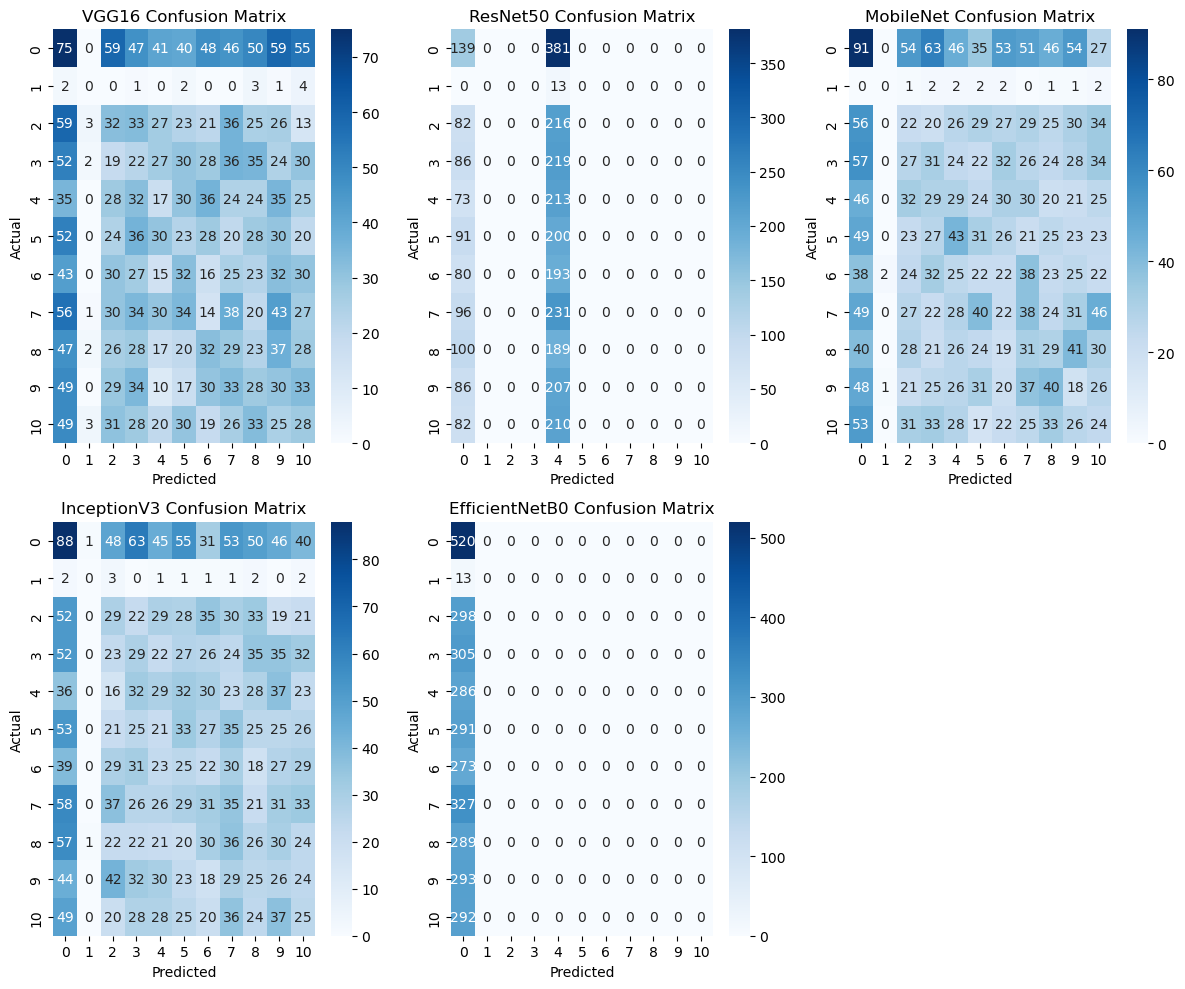

In [11]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Dictionary of models
models = {
    "VGG16": "C:/Users/91886/Desktop/My Computer/Project_guvi/fish classification deep learning/vgg16_trained_model.h5",
    "ResNet50": "C:/Users/91886/Desktop/My Computer/Project_guvi/fish classification deep learning/resnet50_trained_model.h5",
    "MobileNet": "C:/Users/91886/Desktop/My Computer/Project_guvi/fish classification deep learning/mobilenet_trained_model.h5",
    "InceptionV3": "C:/Users/91886/Desktop/My Computer/Project_guvi/fish classification deep learning/inceptionv3_trained_model.h5",
    "EfficientNetB0": "C:/Users/91886/Desktop/My Computer/Project_guvi/fish classification deep learning/efficientnetb0_trained_model.h5",
}

# Store results
metrics = {}

for model_name, model_path in models.items():
    # Load model
    model = tf.keras.models.load_model(model_path)


 # Evaluate model on test data
    loss, acc = model.evaluate(test_generator)

    # Predict on test data
    y_pred_probs = model.predict(test_generator)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = test_generator.classes  # Get true labels from the generator

    # Compute metrics
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")
    cm = confusion_matrix(y_true, y_pred)

    # Store results
    metrics[model_name] = {
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Confusion Matrix": cm
    }

# Display results
for model, scores in metrics.items():
    print(f"\nModel: {model}")
    for metric, value in scores.items():
        if metric == "Confusion Matrix":
            print(f"{metric}:\n{value}")
        else:
            print(f"{metric}: {value:.4f}")

# Plot Confusion Matrices
plt.figure(figsize=(12, 10))
for i, (model, scores) in enumerate(metrics.items()):
    plt.subplot(2, 3, i + 1)
    sns.heatmap(scores["Confusion Matrix"], annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()